[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sandeshjung/Machine-Learning-Foundation/blob/main/03_Model_evaluation_selection/classification_metrics.ipynb)

In [1]:
# Colab setup: install the shared helpers (mlf_utils) and any extra packages. Does nothing when run locally.
import sys
if "google.colab" in sys.modules:
    get_ipython().run_line_magic("pip", "install -q git+https://github.com/sandeshjung/Machine-Learning-Foundation.git")

### Classification Metrics, ROC/PR Curves, Imbalance & Calibration

A classifier usually outputs a **score** or probability, and a **threshold** turns it into a decision. Different metrics answer different questions:
- *How good are the decisions at this threshold?* Confusion matrix, precision, recall, F1.
- *How well does the score rank positives above negatives, across all thresholds?* ROC-AUC, average precision.
- *Can the probabilities be taken at face value?* Calibration, Brier score.

Everything below is implemented from scratch and checked against `sklearn.metrics`. Theory: [Classification Metrics](README.md#classification-metrics)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata
from sklearn import metrics
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.datasets import make_classification
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from mlf_utils import check_close

sns.set_theme(style="whitegrid")
np.random.seed(42)

#### Data: an imbalanced problem
Only about 10% positives, like fraud detection, disease screening or churn. We split with `stratify=y` so both sets keep the same class ratio.

In [3]:
X, y = make_classification(n_samples=5000, n_features=10, n_informative=4, n_redundant=2,
                           weights=[0.9, 0.1], flip_y=0.02, class_sep=1.5, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
print(f"Positive rate: train = {y_train.mean():.3f}, test = {y_test.mean():.3f}")

logreg = LogisticRegression(max_iter=1000).fit(X_train, y_train)
scores = logreg.predict_proba(X_test)[:, 1]            # P(y = 1 | x)
y_pred = (scores >= 0.5).astype(int)

Positive rate: train = 0.106, test = 0.107


#### The accuracy paradox
A "model" that always predicts the majority class scores about 90% accuracy while catching **zero** positives. On imbalanced data, accuracy alone is meaningless.

In [4]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
for name, pred in [("Always predict 0", dummy.predict(X_test)), ("Logistic regression", y_pred)]:
    print(f"{name:20s} accuracy = {metrics.accuracy_score(y_test, pred):.3f}   recall = {metrics.recall_score(y_test, pred):.3f}")

Always predict 0     accuracy = 0.893   recall = 0.000
Logistic regression  accuracy = 0.922   recall = 0.375


#### Confusion matrix and threshold metrics

| | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | TN | FP (type I error) |
| **Actual 1** | FN (type II error) | TP |

$$\large \text{Precision} = \frac{TP}{TP + FP} \quad \text{Recall (TPR)} = \frac{TP}{TP + FN} \quad \text{Specificity} = \frac{TN}{TN + FP} \quad F_1 = \frac{2 \cdot P \cdot R}{P + R}$$

**Balanced accuracy** $= \frac{1}{2}(\text{TPR} + \text{TNR})$ and the **Matthews correlation coefficient** $\text{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$ both stay informative under class imbalance.

In [5]:
def confusion(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1)); tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0)); fn = np.sum((y_pred == 0) & (y_true == 1))
    return tn, fp, fn, tp

def threshold_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion(y_true, y_pred)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn)
    specificity = tn / (tn + fp)
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    denom = np.sqrt(float((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)))
    mcc = (tp * tn - fp * fn) / denom if denom else 0.0       # sklearn also returns 0 when undefined
    return {"accuracy": (tp + tn) / len(y_true), "precision": precision, "recall": recall,
            "specificity": specificity, "f1": f1, "balanced_accuracy": (recall + specificity) / 2, "mcc": mcc}

ours = threshold_metrics(y_test, y_pred)
pd.Series(ours).round(4)

accuracy             0.9220
precision            0.7792
recall               0.3750
specificity          0.9873
f1                   0.5063
balanced_accuracy    0.6812
mcc                  0.5068
dtype: float64

In [6]:
check_close("Confusion matrix vs sklearn", np.array(confusion(y_test, y_pred)), metrics.confusion_matrix(y_test, y_pred).ravel())
reference = {"accuracy": metrics.accuracy_score, "precision": metrics.precision_score, "recall": metrics.recall_score,
             "f1": metrics.f1_score, "balanced_accuracy": metrics.balanced_accuracy_score, "mcc": metrics.matthews_corrcoef}
for name, fn in reference.items():
    check_close(f"{name} vs sklearn", ours[name], fn(y_test, y_pred))
check_close("specificity vs sklearn (recall of class 0)", ours["specificity"], metrics.recall_score(y_test, y_pred, pos_label=0))

✓ Confusion matrix vs sklearn: matches (max |diff| = 0.00e+00)
✓ accuracy vs sklearn: matches (max |diff| = 0.00e+00)
✓ precision vs sklearn: matches (max |diff| = 0.00e+00)
✓ recall vs sklearn: matches (max |diff| = 0.00e+00)
✓ f1 vs sklearn: matches (max |diff| = 0.00e+00)
✓ balanced_accuracy vs sklearn: matches (max |diff| = 0.00e+00)
✓ mcc vs sklearn: matches (max |diff| = 0.00e+00)
✓ specificity vs sklearn (recall of class 0): matches (max |diff| = 0.00e+00)


#### ROC curve and AUC
Sweep the threshold from $+\infty$ down to $-\infty$ and plot **TPR against FPR** at every distinct score. The **area under the curve** has a neat probabilistic meaning: it is the probability that a random positive gets a higher score than a random negative (ties count ½). That is exactly the normalised **Mann-Whitney U** statistic, so AUC can also be computed from ranks with no curve at all:

$$\large \text{AUC} = \frac{\sum_{i \in \text{pos}} \text{rank}(s_i) - \frac{n_+(n_+ + 1)}{2}}{n_+ \, n_-}$$

In [7]:
def binary_clf_curve(y_true, scores):
    """Cumulative TP and FP counts at each distinct threshold (highest score first)."""
    order = np.argsort(-scores, kind="mergesort")
    s, t = scores[order], y_true[order]
    last_of_each_score = np.r_[np.where(np.diff(s))[0], len(s) - 1]
    tps = np.cumsum(t)[last_of_each_score]
    fps = (last_of_each_score + 1) - tps
    return fps, tps, s[last_of_each_score]

def roc_curve_scratch(y_true, scores):
    fps, tps, thr = binary_clf_curve(y_true, scores)
    return np.r_[0, fps / fps[-1]], np.r_[0, tps / tps[-1]], np.r_[np.inf, thr]

def auc_trapezoid(x, y):
    return np.sum(np.diff(x) * (y[1:] + y[:-1]) / 2)

def auc_mann_whitney(y_true, scores):
    ranks = rankdata(scores)                            # average ranks handle ties
    n_pos, n_neg = y_true.sum(), len(y_true) - y_true.sum()
    return (ranks[y_true == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

fpr, tpr, thresholds = roc_curve_scratch(y_test, scores)
print(f"AUC (trapezoid) = {auc_trapezoid(fpr, tpr):.4f}, AUC (Mann-Whitney ranks) = {auc_mann_whitney(y_test, scores):.4f}")

AUC (trapezoid) = 0.8116, AUC (Mann-Whitney ranks) = 0.8116


In [8]:
sk_fpr, sk_tpr, sk_thr = metrics.roc_curve(y_test, scores, drop_intermediate=False)
check_close("ROC curve FPR vs sklearn", fpr, sk_fpr)
check_close("ROC curve TPR vs sklearn", tpr, sk_tpr)
check_close("ROC thresholds vs sklearn (after the leading inf)", thresholds[1:], sk_thr[1:])
check_close("AUC (trapezoid) vs roc_auc_score", auc_trapezoid(fpr, tpr), metrics.roc_auc_score(y_test, scores))
check_close("AUC (Mann-Whitney) vs roc_auc_score", auc_mann_whitney(y_test, scores), metrics.roc_auc_score(y_test, scores))

✓ ROC curve FPR vs sklearn: matches (max |diff| = 0.00e+00)
✓ ROC curve TPR vs sklearn: matches (max |diff| = 0.00e+00)
✓ ROC thresholds vs sklearn (after the leading inf): matches (max |diff| = 0.00e+00)
✓ AUC (trapezoid) vs roc_auc_score: matches (max |diff| = 0.00e+00)
✓ AUC (Mann-Whitney) vs roc_auc_score: matches (max |diff| = 1.11e-16)


#### Precision-recall curve and average precision
On imbalanced data the ROC curve can look flattering: FPR divides by the (huge) number of negatives, so even many false positives barely move it. The **precision-recall curve** focuses on the positive class. Its summary is **average precision**, the precision averaged over the recall steps:

$$\large \text{AP} = \sum_{k} (R_k - R_{k-1})\, P_k$$

A random classifier's AP equals the positive rate (about 0.1 here), while its ROC-AUC is always 0.5. Keep that baseline in mind when reading AP.

In [9]:
def pr_curve_scratch(y_true, scores):
    fps, tps, thr = binary_clf_curve(y_true, scores)
    precision, recall = tps / (tps + fps), tps / tps[-1]
    return precision, recall, thr

def average_precision_scratch(y_true, scores):
    precision, recall, _ = pr_curve_scratch(y_true, scores)
    return np.sum(np.diff(np.r_[0, recall]) * precision)

precision, recall, pr_thr = pr_curve_scratch(y_test, scores)
sk_precision, sk_recall, _ = metrics.precision_recall_curve(y_test, scores)
# sklearn orders the curve by increasing threshold and appends the point (recall=0, precision=1)
check_close("PR curve precision vs sklearn", precision[::-1], sk_precision[:-1])
check_close("PR curve recall vs sklearn", recall[::-1], sk_recall[:-1])
check_close("Average precision vs sklearn", average_precision_scratch(y_test, scores), metrics.average_precision_score(y_test, scores))

✓ PR curve precision vs sklearn: matches (max |diff| = 0.00e+00)
✓ PR curve recall vs sklearn: matches (max |diff| = 0.00e+00)
✓ Average precision vs sklearn: matches (max |diff| = 1.11e-16)


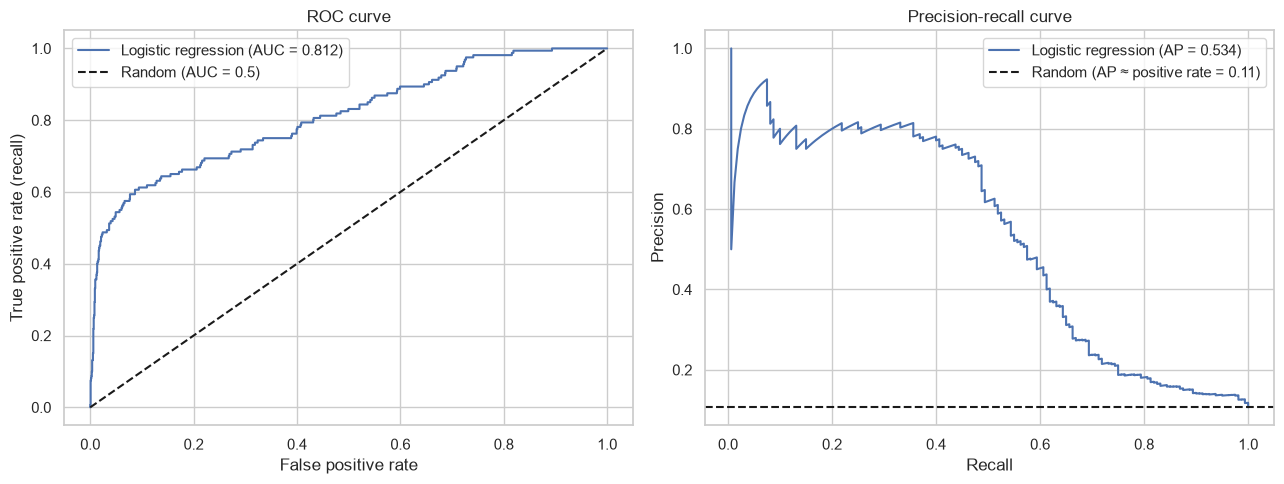

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, label=f"Logistic regression (AUC = {auc_trapezoid(fpr, tpr):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate (recall)"); axes[0].set_title("ROC curve"); axes[0].legend()
axes[1].plot(recall, precision, label=f"Logistic regression (AP = {average_precision_scratch(y_test, scores):.3f})")
axes[1].axhline(y_test.mean(), color="k", ls="--", label=f"Random (AP ≈ positive rate = {y_test.mean():.2f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("Precision-recall curve"); axes[1].legend()
plt.tight_layout(); plt.show()

#### Try it: move the threshold along the curves
The same threshold is one point on the ROC curve and one point on the PR curve. Lowering it moves you up and to the right on ROC (more TP and more FP), and to the right on PR (higher recall, usually lower precision).

*Interactive: run the notebook locally or in Colab to use the controls. GitHub only renders a static page.*

In [11]:
from ipywidgets import FloatSlider, interact

@interact(threshold=FloatSlider(value=0.5, min=0.01, max=0.99, step=0.01, continuous_update=False))
def explore_threshold(threshold):
    pred = (scores >= threshold).astype(int)
    m = threshold_metrics(y_test, pred)
    tn, fp, fn, tp = confusion(y_test, pred)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    axes[0].plot(fpr, tpr); axes[0].plot(fp / (fp + tn), tp / (tp + fn), "ro", ms=10)
    axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC")
    axes[1].plot(recall, precision); axes[1].plot(m["recall"], m["precision"], "ro", ms=10)
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("Precision-recall")
    sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[2],
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    axes[2].set_title(f"t = {threshold:.2f}: P = {m['precision']:.2f}, R = {m['recall']:.2f}, F1 = {m['f1']:.2f}")
    plt.tight_layout(); plt.show()

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='threshold', max=0.99, min=0…

#### Choosing a threshold
0.5 is only right if both kinds of error cost the same. Two common strategies:
- **Maximise F1** (or $F_\beta$, which weights recall $\beta$ times as much as precision).
- **Minimise expected cost:** if a missed positive costs $c_{FN}$ and a false alarm costs $c_{FP}$, pick the threshold minimising $c_{FN} \cdot FN + c_{FP} \cdot FP$. For calibrated probabilities the optimum is near $t^* = \frac{c_{FP}}{c_{FP} + c_{FN}}$.

*Choose thresholds on validation data. Using the test set here keeps the illustration short.*

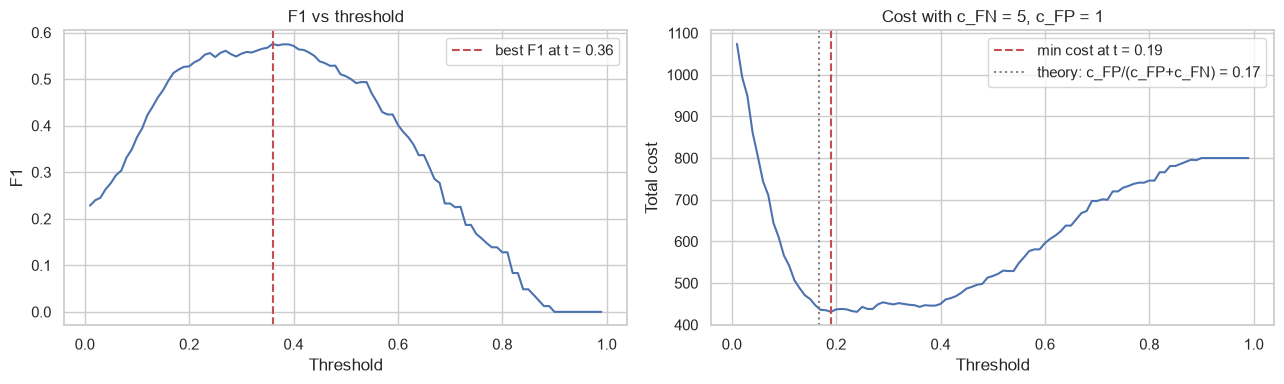

In [12]:
grid = np.linspace(0.01, 0.99, 99)
f1s = [threshold_metrics(y_test, (scores >= t).astype(int))["f1"] for t in grid]
c_fn, c_fp = 5.0, 1.0                       # a missed positive is 5x worse than a false alarm
costs = [c_fn * confusion(y_test, (scores >= t).astype(int))[2] + c_fp * confusion(y_test, (scores >= t).astype(int))[1] for t in grid]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(grid, f1s); axes[0].axvline(grid[np.argmax(f1s)], color="r", ls="--", label=f"best F1 at t = {grid[np.argmax(f1s)]:.2f}")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("F1"); axes[0].legend(); axes[0].set_title("F1 vs threshold")
axes[1].plot(grid, costs); axes[1].axvline(grid[np.argmin(costs)], color="r", ls="--", label=f"min cost at t = {grid[np.argmin(costs)]:.2f}")
axes[1].axvline(c_fp / (c_fp + c_fn), color="gray", ls=":", label=f"theory: c_FP/(c_FP+c_FN) = {c_fp / (c_fp + c_fn):.2f}")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Total cost"); axes[1].legend(); axes[1].set_title(f"Cost with c_FN = {c_fn:.0f}, c_FP = {c_fp:.0f}")
plt.tight_layout(); plt.show()

#### Handling class imbalance
Three standard levers, compared below:
1. **Threshold moving:** keep the model and lower the threshold (cheap, and often the most effective).
2. **Class weights:** weight the loss so each class contributes equally (`class_weight="balanced"`, i.e. $w_c = \frac{n}{K \cdot n_c}$).
3. **Resampling:** randomly oversample the minority class (or undersample the majority) in the **training set only**. SMOTE interpolates synthetic minority points.

Watch what each lever changes. **Threshold moving** leaves the scores untouched, so ROC-AUC and AP are identical to the baseline *by construction*. Only the decisions change. **Re-weighting and resampling** refit the model itself. Here they raise recall at $t = 0.5$ dramatically and nudge ROC-AUC up, but *lower* average precision. They also inflate the predicted probabilities towards the minority class, so the scores are no longer calibrated. If you re-weight, re-tune the threshold or re-calibrate. Threshold moving on an unweighted model is often the simplest good option.

In [13]:
rng = np.random.RandomState(0)
pos_idx = np.where(y_train == 1)[0]
extra = rng.choice(pos_idx, size=(y_train == 0).sum() - len(pos_idx), replace=True)     # oversample positives to 50/50
X_over, y_over = np.vstack([X_train, X_train[extra]]), np.r_[y_train, y_train[extra]]

variants = {
    "Baseline (t = 0.5)": (logreg, 0.5),
    "Threshold moving (best-F1 t)": (logreg, grid[np.argmax(f1s)]),
    "class_weight='balanced'": (LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_train, y_train), 0.5),
    "Random oversampling": (LogisticRegression(max_iter=1000).fit(X_over, y_over), 0.5),
}
rows = {}
for name, (model, t) in variants.items():
    s = model.predict_proba(X_test)[:, 1]
    m = threshold_metrics(y_test, (s >= t).astype(int))
    rows[name] = {"precision": m["precision"], "recall": m["recall"], "f1": m["f1"], "balanced_acc": m["balanced_accuracy"],
                  "ROC-AUC": metrics.roc_auc_score(y_test, s), "AP": metrics.average_precision_score(y_test, s)}
pd.DataFrame(rows).T.round(3)

,precision,recall,f1,balanced_acc,ROC-AUC,AP
Baseline (t = 0.5),0.779,0.375,0.506,0.681,0.812,0.534
Threshold moving (best-F1 t),0.703,0.488,0.576,0.731,0.812,0.534
class_weight='balanced',0.332,0.750,0.461,0.785,0.844,0.435
Random oversampling,0.331,0.750,0.459,0.784,0.846,0.431


#### Calibration
A model is **calibrated** if, among all samples it gives probability 0.8, about 80% are actually positive. A **reliability diagram** bins the predictions and plots the mean predicted probability against the observed positive rate in each bin (the diagonal is perfect). The **Brier score** $\frac{1}{n}\sum_i (p_i - y_i)^2$ summarises calibration and sharpness together (lower is better).

Logistic regression is usually well calibrated, because it directly minimises log-loss. Naive Bayes tends to push probabilities towards 0 and 1, because its independence assumption double-counts correlated evidence (this dataset has redundant features). Compare the prediction histograms below: it has a worse Brier score than logistic regression. `CalibratedClassifierCV` fixes a model's probabilities after the fact with isotonic regression or Platt (sigmoid) scaling fitted on held-out folds.

In [14]:
def brier_scratch(y_true, prob):
    return np.mean((prob - y_true) ** 2)

def calibration_curve_scratch(y_true, prob, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.searchsorted(edges[1:-1], prob)          # same binning rule as sklearn
    total = np.bincount(bin_ids, minlength=n_bins)
    nonempty = total > 0
    frac_pos = np.bincount(bin_ids, weights=y_true, minlength=n_bins)[nonempty] / total[nonempty]
    mean_pred = np.bincount(bin_ids, weights=prob, minlength=n_bins)[nonempty] / total[nonempty]
    return frac_pos, mean_pred

nb = GaussianNB().fit(X_train, y_train)
nb_calibrated = CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=5).fit(X_train, y_train)
probs = {"Logistic regression": logreg.predict_proba(X_test)[:, 1],
         "Gaussian naive Bayes": nb.predict_proba(X_test)[:, 1],
         "Naive Bayes + isotonic calibration": nb_calibrated.predict_proba(X_test)[:, 1]}

for name, p in probs.items():
    check_close(f"{name}: Brier score vs sklearn", brier_scratch(y_test, p), metrics.brier_score_loss(y_test, p))
    ours_curve = calibration_curve_scratch(y_test, p)
    sk_curve = calibration_curve(y_test, p, n_bins=10, strategy="uniform")
    check_close(f"{name}: calibration curve vs sklearn", np.concatenate(ours_curve), np.concatenate(sk_curve))

✓ Logistic regression: Brier score vs sklearn: matches (max |diff| = 0.00e+00)
✓ Logistic regression: calibration curve vs sklearn: matches (max |diff| = 0.00e+00)
✓ Gaussian naive Bayes: Brier score vs sklearn: matches (max |diff| = 1.39e-17)
✓ Gaussian naive Bayes: calibration curve vs sklearn: matches (max |diff| = 0.00e+00)
✓ Naive Bayes + isotonic calibration: Brier score vs sklearn: matches (max |diff| = 0.00e+00)
✓ Naive Bayes + isotonic calibration: calibration curve vs sklearn: matches (max |diff| = 0.00e+00)


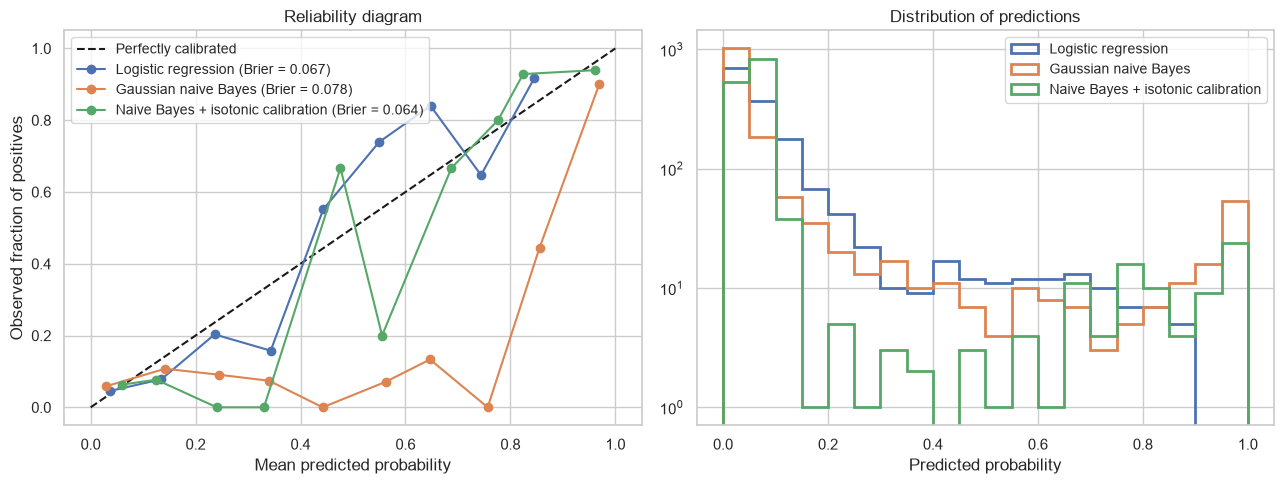

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
for name, p in probs.items():
    frac_pos, mean_pred = calibration_curve_scratch(y_test, p)
    axes[0].plot(mean_pred, frac_pos, "o-", label=f"{name} (Brier = {brier_scratch(y_test, p):.3f})")
    axes[1].hist(p, bins=20, range=(0, 1), histtype="step", lw=2, label=name)
axes[0].set_xlabel("Mean predicted probability"); axes[0].set_ylabel("Observed fraction of positives")
axes[0].set_title("Reliability diagram"); axes[0].legend(fontsize="small")
axes[1].set_yscale("log"); axes[1].set_xlabel("Predicted probability"); axes[1].set_title("Distribution of predictions"); axes[1].legend(fontsize="small")
plt.tight_layout(); plt.show()

#### Summary
| Question | Metric | Notes |
|---|---|---|
| Overall correctness (balanced classes) | Accuracy | Misleading under imbalance |
| Of the flagged cases, how many are real? | Precision | Matters when false alarms are expensive |
| Of the real cases, how many did we catch? | Recall / TPR | Matters when misses are expensive |
| One number for both | $F_1$ / $F_\beta$, MCC, balanced accuracy | MCC and balanced accuracy handle imbalance well |
| Ranking quality, threshold-free | ROC-AUC | Baseline 0.5, can look optimistic under heavy imbalance |
| Ranking quality for the positive class | Average precision (PR-AUC) | Baseline = positive rate |
| Are the probabilities trustworthy? | Reliability diagram, Brier score, log-loss | Fix with `CalibratedClassifierCV` |

For **multi-class** problems, precision, recall and F1 are computed per class and then averaged: **macro** (unweighted mean over classes), **weighted** (by class support), or **micro** (pool all TP/FP/FN, which equals accuracy for single-label problems).